# Customer Intelligence System using Clustering

## Project Overview

This project develops a Customer Intelligence System using unsupervised machine learning techniques. The objective is to identify meaningful groups of countries based on socio-economic and health indicators.

The project applies:

- Data Cleaning
- Feature Scaling
- K-Means Clustering
- DBSCAN Clustering
- PCA Dimensionality Reduction
- Cluster Evaluation using Silhouette Score

The insights generated can help identify high-development, developing, and economically vulnerable regions.

In [29]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Dataset Loading

The dataset contains socio-economic indicators for multiple countries.

Important features include:

- Child Mortality
- Exports
- Health Spending
- Imports
- Income
- Inflation
- Life Expectancy
- Total Fertility
- GDP Per Capita

The goal is to group countries with similar characteristics.

In [30]:
df = pd.read_csv("Country-data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (167, 10)


,country,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,Afghanistan,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,Albania,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,Algeria,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,Angola,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,Antigua and Barbuda,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


In [31]:
print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())


Columns:
['country', 'child_mort', 'exports', 'health', 'imports', 'income', 'inflation', 'life_expec', 'total_fer', 'gdpp']

Missing Values:
country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

Duplicate Rows:
0


# Initial Dataset Inspection

Before performing clustering, the dataset is inspected for:

- Missing values
- Duplicate records
- Incorrect data types
- Extra spaces in column names

In [32]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 167 entries, 0 to 166
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   country     167 non-null    object 
 1   child_mort  167 non-null    float64
 2   exports     167 non-null    float64
 3   health      167 non-null    float64
 4   imports     167 non-null    float64
 5   income      167 non-null    int64  
 6   inflation   167 non-null    float64
 7   life_expec  167 non-null    float64
 8   total_fer   167 non-null    float64
 9   gdpp        167 non-null    int64  
dtypes: float64(7), int64(2), object(1)
memory usage: 13.2+ KB


In [33]:
df.isnull().sum()

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64

In [34]:
df.describe()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
count,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000,167.000000
mean,38.270060,41.108976,6.815689,46.890215,17144.688623,7.781832,70.555689,2.947964,12964.155689
std,40.328931,27.412010,2.746837,24.209589,19278.067698,10.570704,8.893172,1.513848,18328.704809
min,2.600000,0.109000,1.810000,0.065900,609.000000,-4.210000,32.100000,1.150000,231.000000
25%,8.250000,23.800000,4.920000,30.200000,3355.000000,1.810000,65.300000,1.795000,1330.000000
50%,19.300000,35.000000,6.320000,43.300000,9960.000000,5.390000,73.100000,2.410000,4660.000000
75%,62.100000,51.350000,8.600000,58.750000,22800.000000,10.750000,76.800000,3.880000,14050.000000
max,208.000000,200.000000,17.900000,174.000000,125000.000000,104.000000,82.800000,7.490000,105000.000000


# Exploratory Data Analysis

Correlation analysis helps identify relationships among socio-economic indicators.

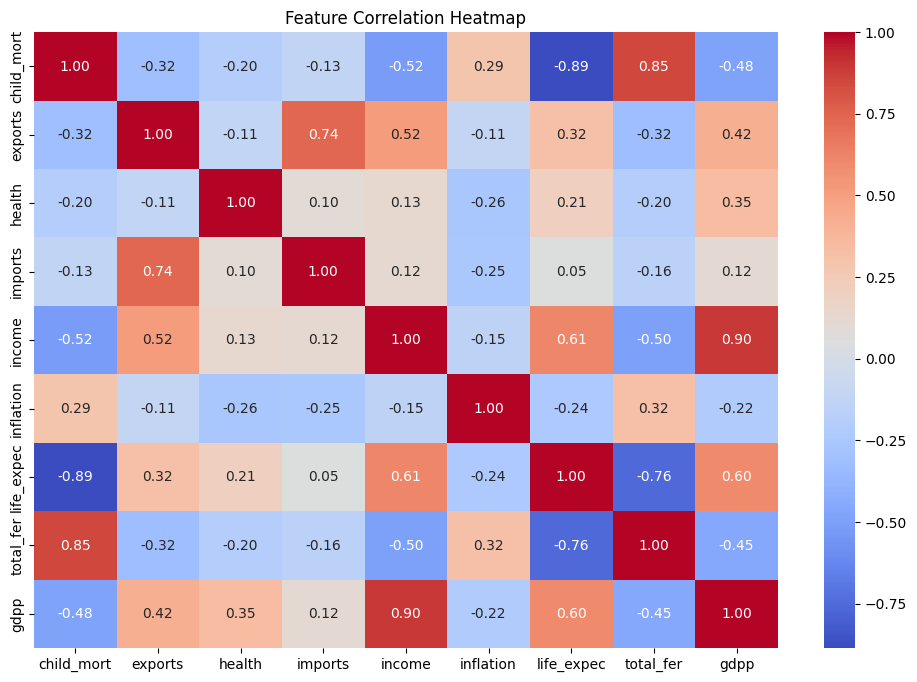

In [35]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.drop("country",axis=1).corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Feature Correlation Heatmap")

plt.show()

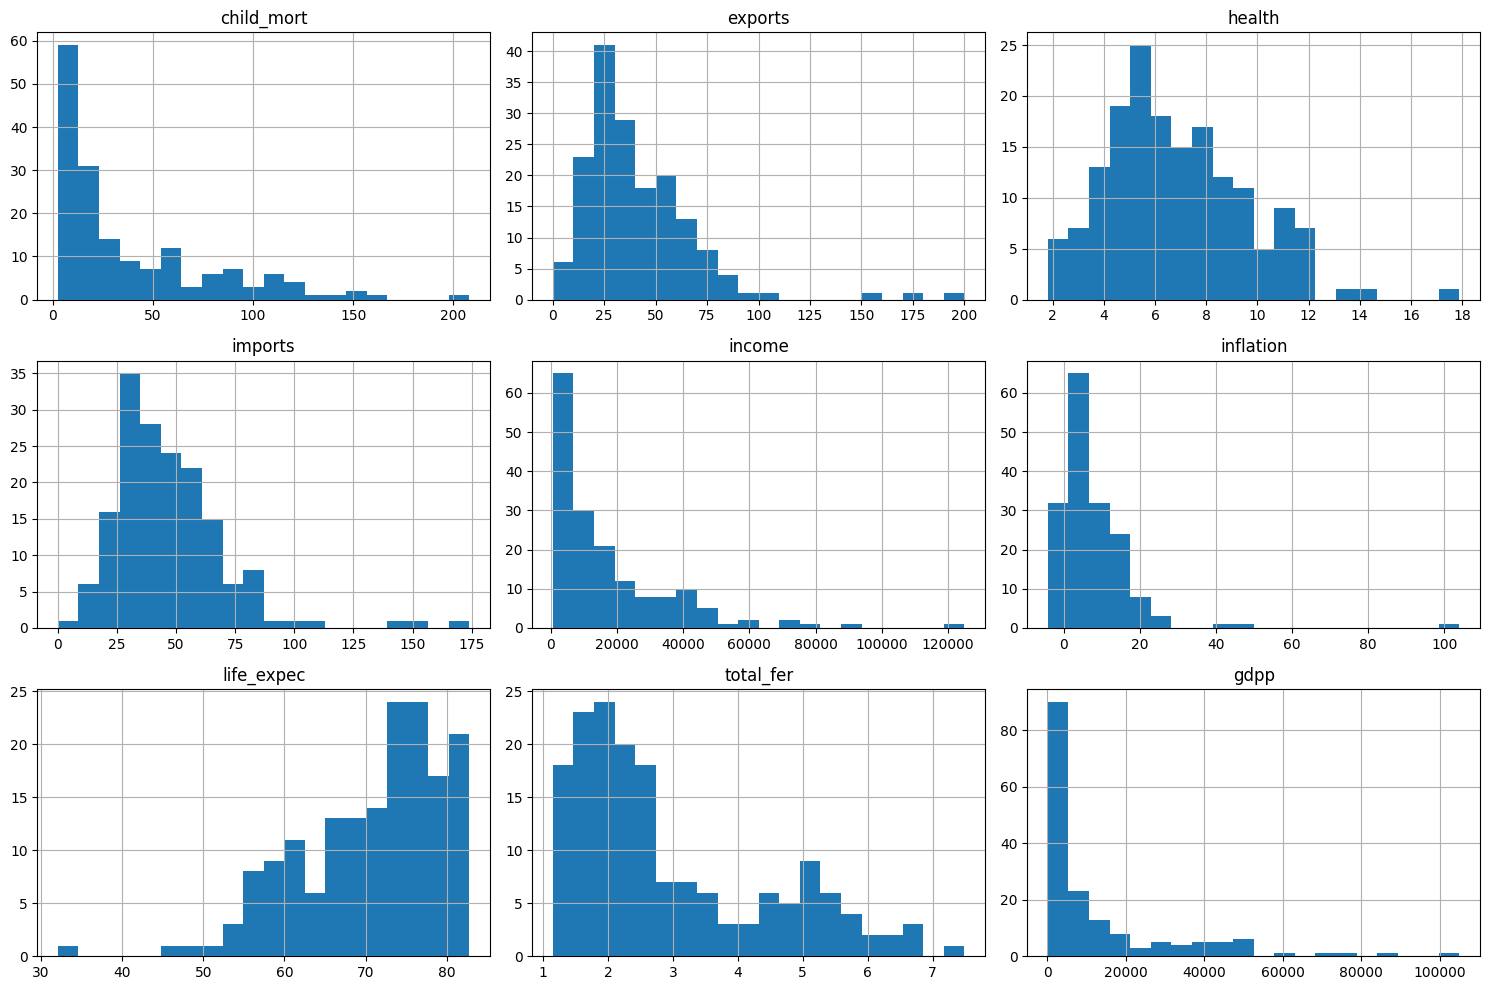

In [36]:
df.drop("country",axis=1).hist(
    figsize=(15,10),
    bins=20
)

plt.tight_layout()
plt.show()

# Data Cleaning

The following preprocessing steps are performed:

1. Remove extra spaces from column names.
2. Remove duplicate rows.
3. Convert all numerical columns into numeric format.
4. Replace missing values using median imputation.

In [37]:
df.columns = df.columns.str.strip()

df = df.drop_duplicates()

for col in df.columns:
    if col != 'country':
        df[col] = pd.to_numeric(df[col], errors='coerce')

numeric_cols = df.select_dtypes(include=np.number).columns

for col in numeric_cols:
    df[col].fillna(df[col].median(), inplace=True)

print(df.isnull().sum())

country       0
child_mort    0
exports       0
health        0
imports       0
income        0
inflation     0
life_expec    0
total_fer     0
gdpp          0
dtype: int64


# Feature Selection

The country name is an identifier and does not contribute to clustering.

Therefore:

- Country column is separated.
- Only numerical features are used.

In [38]:
countries = df['country']

X = df.drop('country', axis=1)

X.head()

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,90.2,10.0,7.58,44.9,1610,9.44,56.2,5.82,553
1,16.6,28.0,6.55,48.6,9930,4.49,76.3,1.65,4090
2,27.3,38.4,4.17,31.4,12900,16.10,76.5,2.89,4460
3,119.0,62.3,2.85,42.9,5900,22.40,60.1,6.16,3530
4,10.3,45.5,6.03,58.9,19100,1.44,76.8,2.13,12200


# Feature Scaling

Clustering algorithms are distance-based.

Features such as GDP and Inflation have vastly different scales.

StandardScaler is applied to normalize all variables.

In [39]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_scaled[:5]

array([[ 1.29153238, -1.13827979,  0.27908825, -0.08245496, -0.8082454 ,
         0.15733622, -1.61909203,  1.90288227, -0.67917961],
       [-0.5389489 , -0.47965843, -0.09701618,  0.07083669, -0.3753689 ,
        -0.31234747,  0.64786643, -0.85997281, -0.48562324],
       [-0.27283273, -0.09912164, -0.96607302, -0.64176233, -0.22084447,
         0.78927429,  0.67042323, -0.0384044 , -0.46537561],
       [ 2.00780766,  0.77538117, -1.44807093, -0.16531531, -0.58504345,
         1.38705353, -1.17923442,  2.12815103, -0.51626829],
       [-0.69563412,  0.1606679 , -0.28689415,  0.4975675 ,  0.10173177,
        -0.60174853,  0.70425843, -0.54194633, -0.04181713]])

# Optimal Cluster Selection using Elbow Method

The Elbow Method evaluates clustering performance for different values of K.

The point where inertia reduction starts slowing down is selected as the optimal number of clusters.

In [40]:
inertia = []

k_values = range(2,11)

for k in k_values:
    
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    model.fit(X_scaled)
    
    inertia.append(model.inertia_)

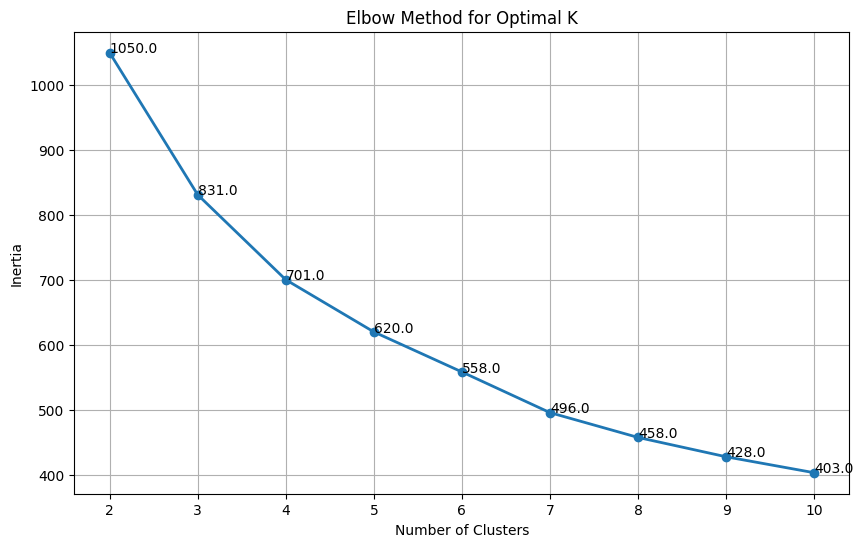

In [41]:
plt.figure(figsize=(10,6))

plt.plot(
    k_values,
    inertia,
    marker='o',
    linewidth=2
)

for i,j in zip(k_values,inertia):
    plt.text(i,j,round(j,0))

plt.title("Elbow Method for Optimal K")
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.grid(True)

plt.show()

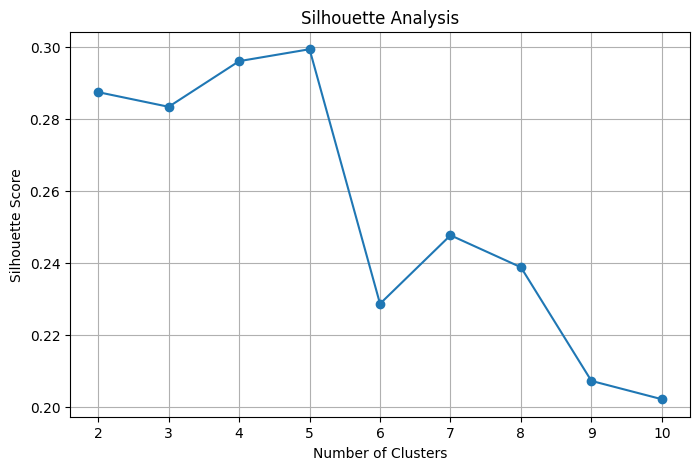

In [42]:
from sklearn.metrics import silhouette_score

sil_scores = []

for k in range(2,11):
    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = model.fit_predict(X_scaled)

    sil_scores.append(
        silhouette_score(
            X_scaled,
            labels
        )
    )

plt.figure(figsize=(8,5))
plt.plot(
    range(2,11),
    sil_scores,
    marker='o'
)

plt.title("Silhouette Analysis")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.grid(True)

plt.show()

In [43]:
best_silhouette_k = (
    np.argmax(sil_scores) + 2
)

print(
    "Best K based on Silhouette Score:",
    best_silhouette_k
)

Best K based on Silhouette Score: 5


# K-Means Clustering

Based on the Elbow Method, the number of clusters is selected as:

**K = 3**

The K-Means algorithm is then trained on the standardized dataset.

In [44]:
best_k = 3

kmeans = KMeans(
    n_clusters=best_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(X_scaled)

df["KMeans_Cluster"] = kmeans_labels

df.head()
print("Cluster Centers (Scaled Space):")

pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)

Cluster Centers (Scaled Space):


,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp
0,-0.827449,0.645080,0.727411,0.190639,1.484243,-0.484921,1.079579,-0.791877,1.615995
1,1.360218,-0.437533,-0.155984,-0.189204,-0.686894,0.402111,-1.282180,1.364944,-0.604242
2,-0.406453,-0.031653,-0.224471,0.024162,-0.251770,-0.017167,0.254734,-0.424343,-0.354481


KMeans_Cluster
2    84
1    47
0    36
Name: count, dtype: int64


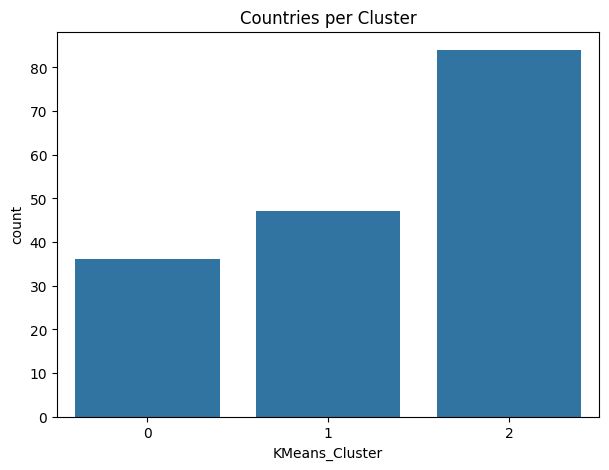

In [45]:
cluster_counts = df["KMeans_Cluster"].value_counts()

print(cluster_counts)
cluster_summary = (
    df.groupby("KMeans_Cluster")
    .mean(numeric_only=True)
)

cluster_summary

plt.figure(figsize=(7,5))

sns.countplot(
    x="KMeans_Cluster",
    data=df
)

plt.title("Countries per Cluster")

plt.show()

In [46]:
feature_importance = (
    cluster_summary.max()
    -
    cluster_summary.min()
)

feature_importance = (
    feature_importance
    .sort_values(
        ascending=False
    )
)

print(
    "Features Driving Segmentation"
)

feature_importance

Features Driving Segmentation


income        41729.817967
gdpp          40572.061466
child_mort       87.961702
exports          29.587612
life_expec       20.940544
inflation         9.348431
imports           9.168262
total_fer         3.255307
health            2.606825
dtype: float64

# Cluster Evaluation

Silhouette Score is used to evaluate cluster quality.

Higher values indicate:

- Better separation
- Better compactness
- More stable clustering structure

In [47]:
score = silhouette_score(
    X_scaled,
    kmeans_labels
)

print("Silhouette Score:", round(score,4))

Silhouette Score: 0.2833


# DBSCAN Clustering

To compare K-Means performance, DBSCAN is applied.

DBSCAN can detect:

- Noise points
- Arbitrary cluster shapes
- Density-based groupings

In [48]:
dbscan = DBSCAN(
    eps=1.5,
    min_samples=5
)

db_labels = dbscan.fit_predict(X_scaled)

df["DBSCAN_Cluster"] = db_labels

print(
    "Unique DBSCAN Labels:",
    np.unique(db_labels)
)

print(
    "Number of Noise Points:",
    np.sum(db_labels==-1)
)

print(
    "Number of Clusters:",
    len(set(db_labels)) -
    (1 if -1 in db_labels else 0)
)

Unique DBSCAN Labels: [-1  0]
Number of Noise Points: 30
Number of Clusters: 1


In [49]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
print(
    "Explained Variance Ratio:",
    pca.explained_variance_ratio_
)

print(
    "Total Variance Explained:",
    round(
        pca.explained_variance_ratio_.sum()*100,
        2
    ),
    "%"
)

Explained Variance Ratio: [0.4595174  0.17181626]
Total Variance Explained: 63.13 %


# PCA for Visualization

The dataset contains multiple dimensions.

Principal Component Analysis (PCA) reduces the dataset into two dimensions for visualization while preserving maximum information.

In [50]:
pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    columns=['PC1','PC2']
)

pca_df['Cluster'] = kmeans_labels

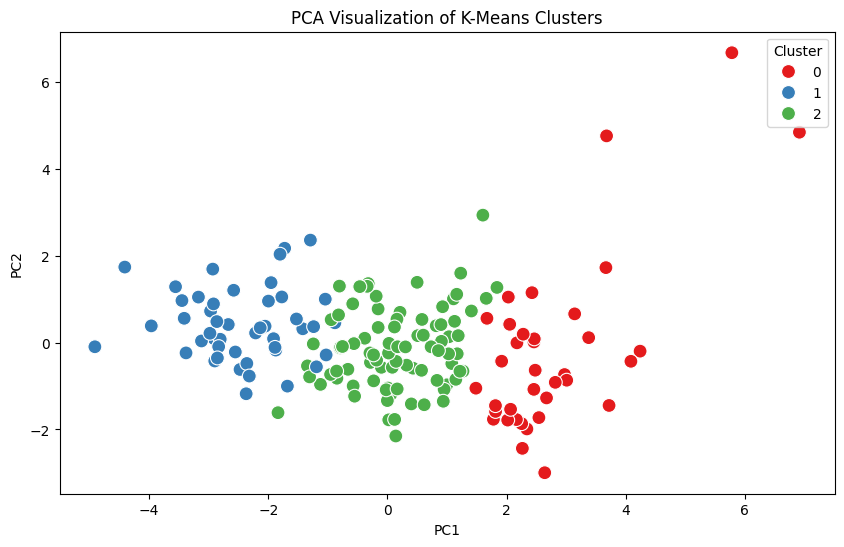

In [51]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.title("PCA Visualization of K-Means Clusters")

plt.show()

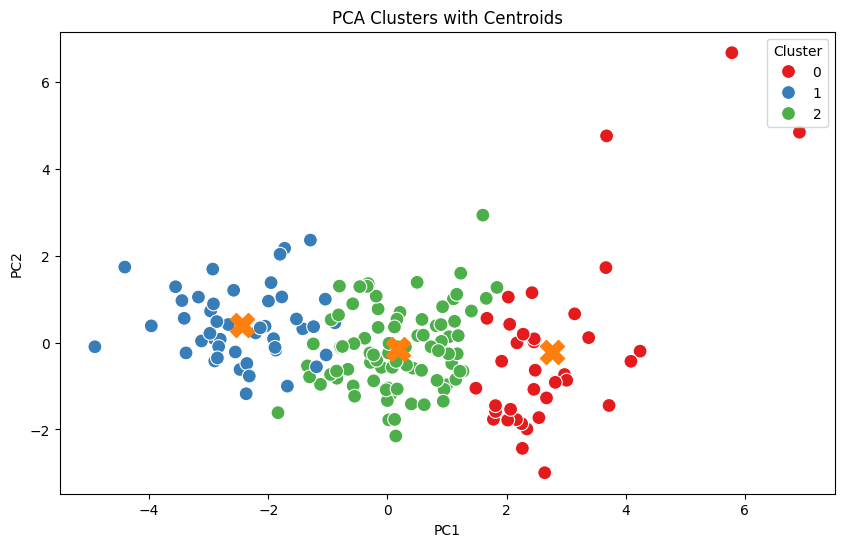

In [52]:
centroids = pd.DataFrame(
    kmeans.cluster_centers_,
    columns=X.columns
)

centroids_pca = pca.transform(
    centroids
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=pca_df,
    x='PC1',
    y='PC2',
    hue='Cluster',
    palette='Set1',
    s=100
)

plt.scatter(
    centroids_pca[:,0],
    centroids_pca[:,1],
    marker='X',
    s=300
)

plt.title(
    "PCA Clusters with Centroids"
)

plt.show()

# Cluster Statistics

Cluster-wise averages are calculated to understand socio-economic patterns.

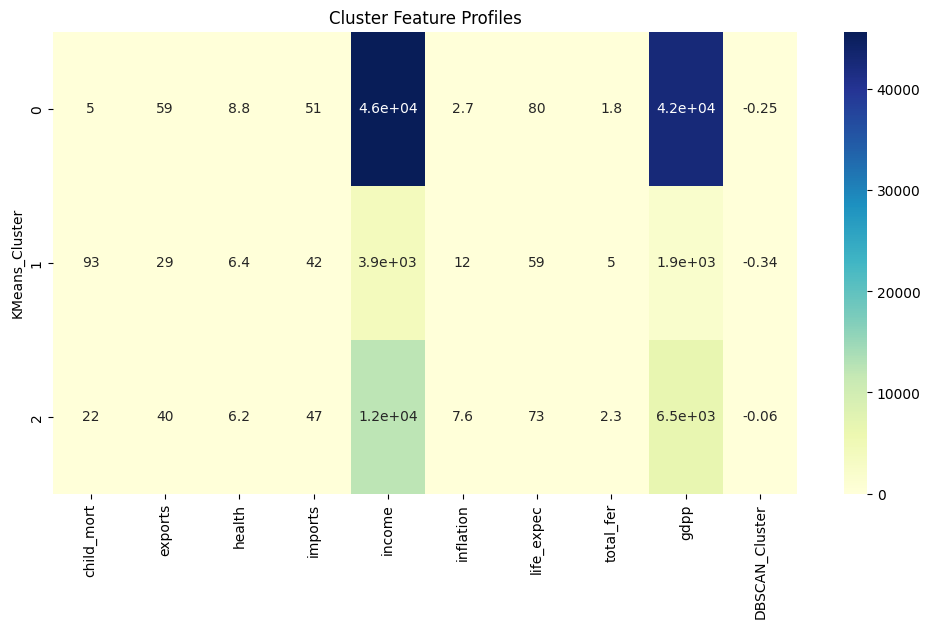

In [53]:
cluster_summary = df.groupby(
    'KMeans_Cluster'
).mean(numeric_only=True)

cluster_summary
plt.figure(figsize=(12,6))

sns.heatmap(
    cluster_summary,
    annot=True,
    cmap="YlGnBu"
)

plt.title(
    "Cluster Feature Profiles"
)

plt.show()

In [54]:
for cluster in sorted(df['KMeans_Cluster'].unique()):
    
    print("\n")
    print("="*50)
    print("Cluster", cluster)
    print("="*50)
    
for cluster in sorted(df['KMeans_Cluster'].unique()):

    print("\n")
    print("="*60)

    print(f"Cluster {cluster}")

    print("="*60)

    countries = (
        df[df['KMeans_Cluster']==cluster]
        ['country']
        .tolist()
    )

    print(countries[:10])

    print(
        f"\nTotal Countries: {len(countries)}"
    )



Cluster 0


Cluster 1


Cluster 2


Cluster 0
['Australia', 'Austria', 'Bahrain', 'Belgium', 'Brunei', 'Canada', 'Cyprus', 'Czech Republic', 'Denmark', 'Finland']

Total Countries: 36


Cluster 1
['Afghanistan', 'Angola', 'Benin', 'Botswana', 'Burkina Faso', 'Burundi', 'Cameroon', 'Central African Republic', 'Chad', 'Comoros']

Total Countries: 47


Cluster 2
['Albania', 'Algeria', 'Antigua and Barbuda', 'Argentina', 'Armenia', 'Azerbaijan', 'Bahamas', 'Bangladesh', 'Barbados', 'Belarus']

Total Countries: 84


In [55]:
cluster_summary = (
    df.groupby("KMeans_Cluster")
    .mean(numeric_only=True)
    .round(2)
)

cluster_summary

,child_mort,exports,health,imports,income,inflation,life_expec,total_fer,gdpp,DBSCAN_Cluster
KMeans_Cluster,,,,,,,,,,
0,5.00,58.74,8.81,51.49,45672.22,2.67,80.13,1.75,42494.44,-0.25
1,92.96,29.15,6.39,42.32,3942.40,12.02,59.19,5.01,1922.38,-0.34
2,21.93,40.24,6.20,47.47,12305.60,7.60,72.81,2.31,6486.45,-0.06


# Observations

### Observation 1
One cluster represents highly developed countries characterized by high GDP per capita, high income levels, low child mortality, and high life expectancy.

### Observation 2
Another cluster contains developing economies with moderate socio-economic indicators and average healthcare outcomes.

### Observation 3
The third cluster contains countries with high child mortality, lower income levels, lower life expectancy, and weaker economic conditions.

### Observation 4
A strong relationship can be observed between income levels and healthcare outcomes. Countries with higher income generally exhibit lower mortality and longer life expectancy.

### Observation 5
The PCA visualization demonstrates reasonably well-separated clusters, indicating that K-Means successfully identified distinct socio-economic segments.

## Conclusion

This project developed a complete Country Intelligence System using unsupervised learning techniques.

Key Findings:

- Three distinct socio-economic country segments were identified.
- GDP, income, child mortality, and life expectancy were the primary drivers of segmentation.
- K-Means achieved a positive Silhouette Score, indicating meaningful cluster separation.
- PCA visualization confirmed clear cluster structure.
- DBSCAN identified potential outlier countries with unique development patterns.

Business Impact:

The generated country segments can support international development planning, economic policy analysis, investment prioritization, and global market expansion strategies.